<a href="https://colab.research.google.com/github/Smarth02/online-shopper-intent-prediction/blob/main/Shopper_Intent_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/Smarth02/online-shopper-intent-prediction/refs/heads/main/online_shoppers_intention.csv")

In [3]:
df.head() #First 5 rows of the dataset

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
#Rename columns
df.rename(columns={
    'Administrative':'AdministrativeCount',
    'Informational': 'InformationalCount',
    'ProductRelated':'ProductRelatedCount',
}, inplace=True)

In [5]:
print("Meaning of each column:")
print("AdministrativeCount: Number of administrative pages visited")
print("Administrative_Duration: Total time spent on administrative pages")
print("InformationalCount: Number of informational pages visited")
print("Informational_Duration: Total time spent on informational pages")
print("ProductRelatedCount: Number of product related pages visited")
print("ProductRelated_Duration: Total time spent on product related pages")
print("BounceRates: Average bounce rate of the pages visited during the session.")
print("ExitRates: Average exit rate of the pages visited during the session")
print("PageValue: Average pages visited before completing transaction.")
print("SpecialDay: Closeness to a special day")
print("Month: Month of the visit")
print("OperatingSystems: The visitor's encoded operating system ID")
print("Browser: The visitor's encoded browser ID")
print("Region: The visitor's encoded region ID")
print("TrafficType: Traffic source type (encoded)")
print("VisitorType: Type of visitor (Returning, new or other)")
print("Weekend: If the visit was on a weekend")
print("Revenue: True if visitor made a purchase and false if not")

Meaning of each column:
AdministrativeCount: Number of administrative pages visited
Administrative_Duration: Total time spent on administrative pages
InformationalCount: Number of informational pages visited
Informational_Duration: Total time spent on informational pages
ProductRelatedCount: Number of product related pages visited
ProductRelated_Duration: Total time spent on product related pages
BounceRates: Average bounce rate of the pages visited during the session.
ExitRates: Average exit rate of the pages visited during the session
PageValue: Average pages visited before completing transaction.
SpecialDay: Closeness to a special day
Month: Month of the visit
OperatingSystems: The visitor's encoded operating system ID
Browser: The visitor's encoded browser ID
Region: The visitor's encoded region ID
TrafficType: Traffic source type (encoded)
VisitorType: Type of visitor (Returning, new or other)
Weekend: If the visit was on a weekend
Revenue: True if visitor made a purchase and fals

In [6]:
#Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AdministrativeCount      12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   InformationalCount       12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelatedCount      12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [7]:
#Statistical Summary of the dataset
df.describe()

,AdministrativeCount,Administrative_Duration,InformationalCount,Informational_Duration,ProductRelatedCount,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [8]:
print("Count of null values")
df.isna().sum()

Count of null values


,0
AdministrativeCount,0
Administrative_Duration,0
InformationalCount,0
Informational_Duration,0
ProductRelatedCount,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [9]:
for col in df.columns:
  print("Unique values in", col)
  print(df[col].unique())

Unique values in AdministrativeCount
[ 0  1  2  4 12  3 10  6  5  9  8 16 13 11  7 18 14 17 19 15 24 22 21 20
 23 27 26]
Unique values in Administrative_Duration
[  0.         53.         64.6       ... 167.9107143 305.125
 150.3571429]
Unique values in InformationalCount
[ 0  1  2  4 16  5  3 14  6 12  7  9 10  8 11 24 13]
Unique values in Informational_Duration
[  0.   120.    16.   ... 547.75 368.25 211.25]
Unique values in ProductRelatedCount
[  1   2  10  19   0   3  16   7   6  23  13  20   8   5  32   4  45  14
  52   9  46  15  22  11  12  36  42  27  90  18  38  17 128  25  30  21
  51  26  28  31  24  50  96  49  68  98  67  55  35  37  29  34  71  63
  87  40  33  54  64  75  39 111  81  61  47  44  88 149  41  79  66  43
 258  80  62  83 173  48  58  57  56  69  82  59 109 287  53  84  78 137
 113  89  65  60 104 129  77  74  93  76  72 194 140 110 132 115  73 328
 160  86 150  95 130 151 117 124 127 125 116 105  92 157 154 220 187 112
 131 159  94 204 142 206 102 313 145  

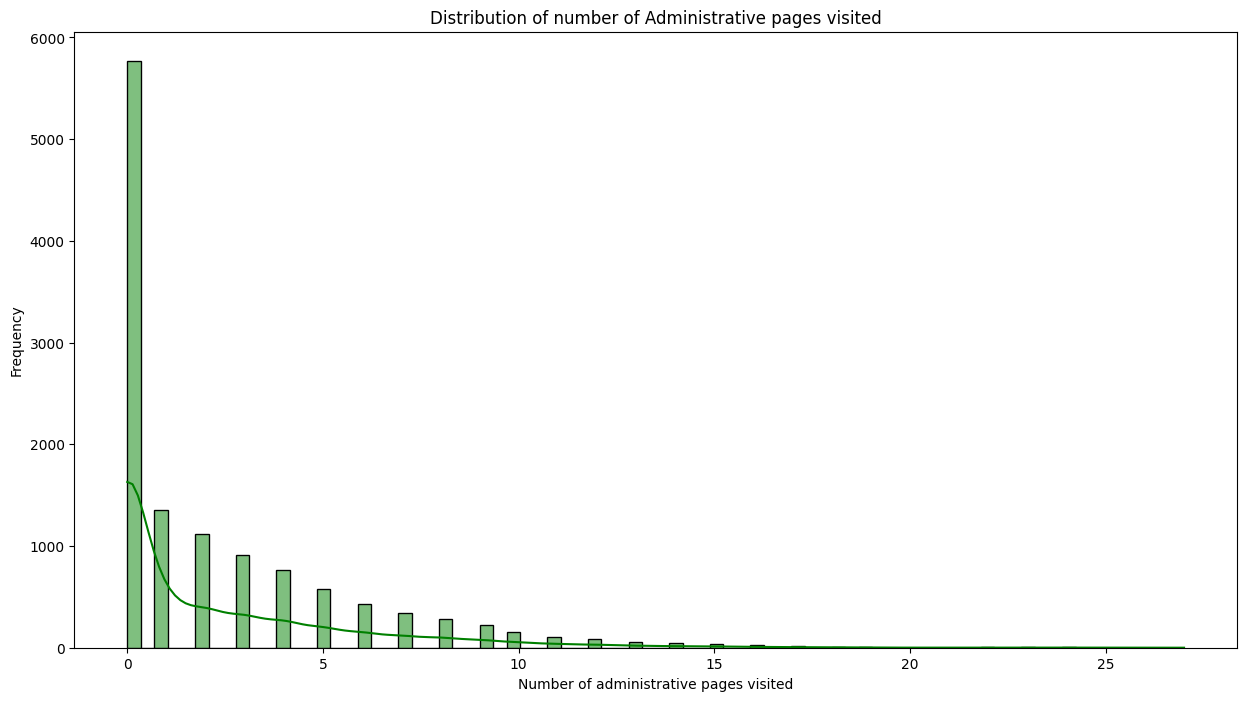

In [10]:
plt.figure(figsize=(15, 8))
sns.histplot(df['AdministrativeCount'], kde=True, color='green')
plt.title('Distribution of number of Administrative pages visited')
plt.xlabel('Number of administrative pages visited')
plt.ylabel('Frequency')
plt.show()

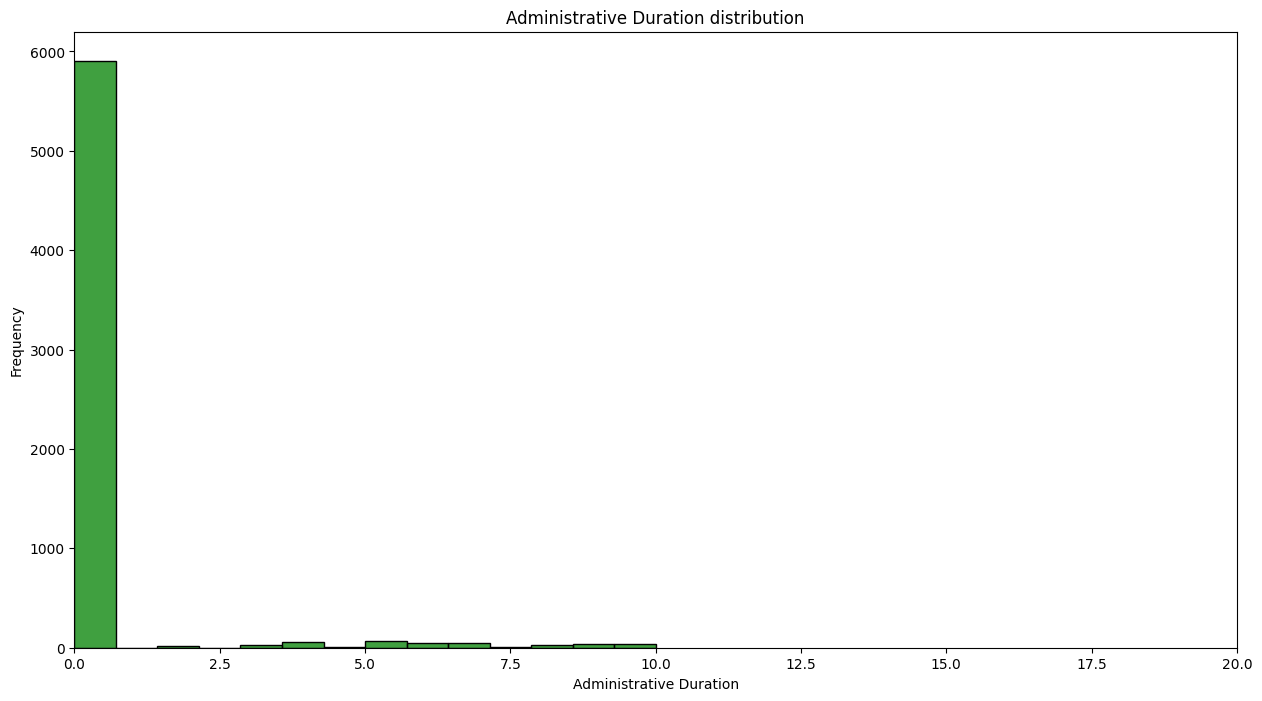

In [11]:
plt.figure(figsize=(15, 8))
sns.histplot(df['Administrative_Duration'], kde=False, color='green', binrange=(0, 10))#, binwidth=10)
plt.xlim(0, 20)
plt.title('Administrative Duration distribution')
plt.xlabel('Administrative Duration')
plt.ylabel('Frequency')
plt.show()

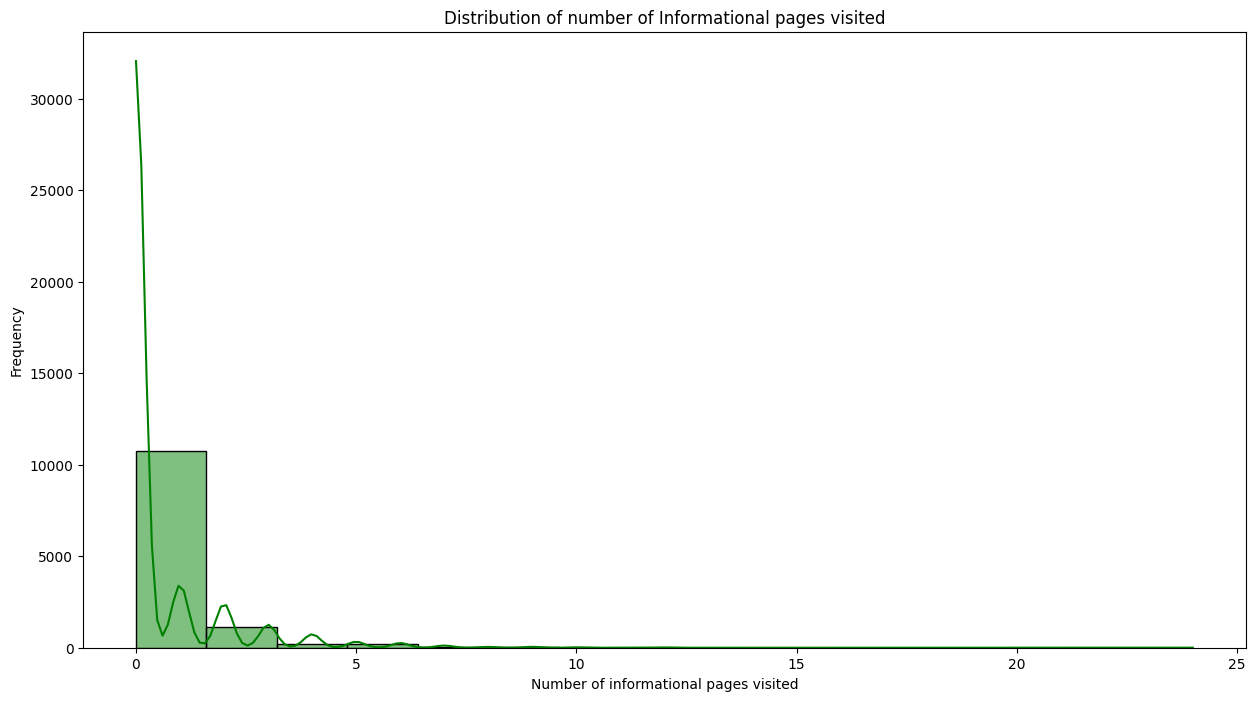

In [12]:
plt.figure(figsize=(15, 8))
sns.histplot(df['InformationalCount'], kde=True, color='green')
plt.title('Distribution of number of Informational pages visited')
plt.xlabel('Number of informational pages visited')
plt.ylabel('Frequency')
plt.show()

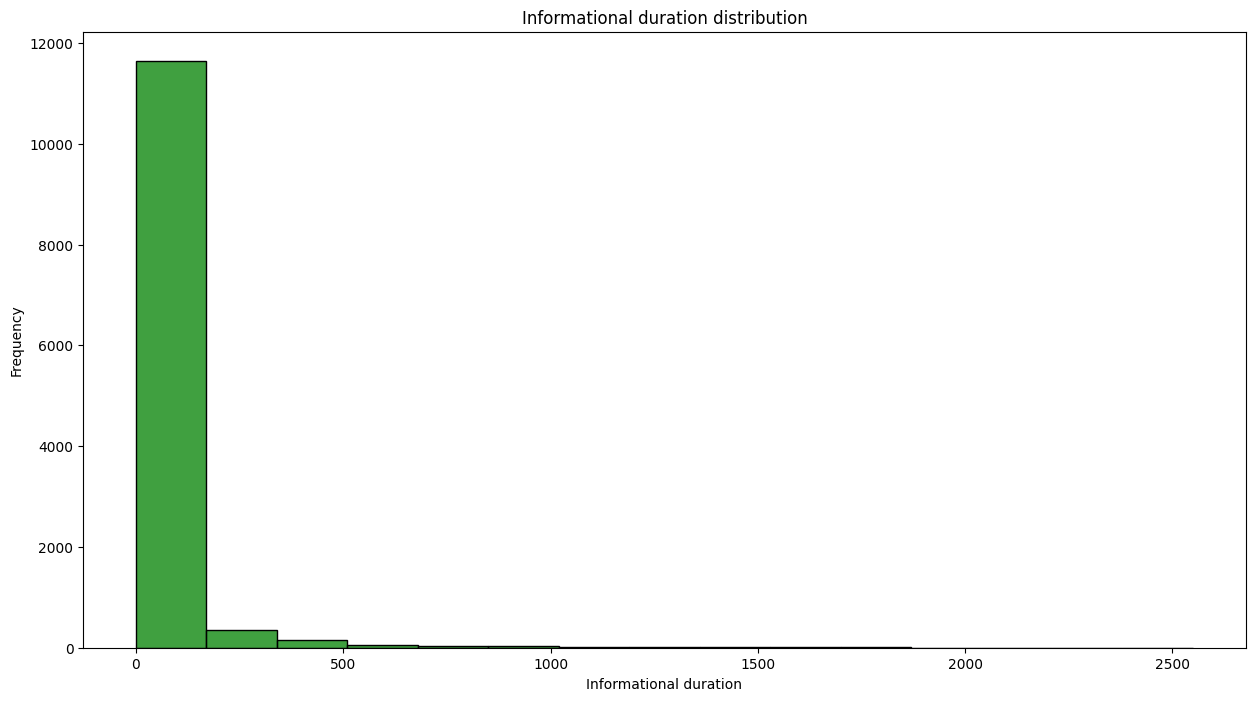

In [13]:
plt.figure(figsize=(15, 8))
sns.histplot(df['Informational_Duration'], kde=False, color='green')
plt.title('Informational duration distribution')
plt.xlabel('Informational duration')
plt.ylabel('Frequency')
plt.show()

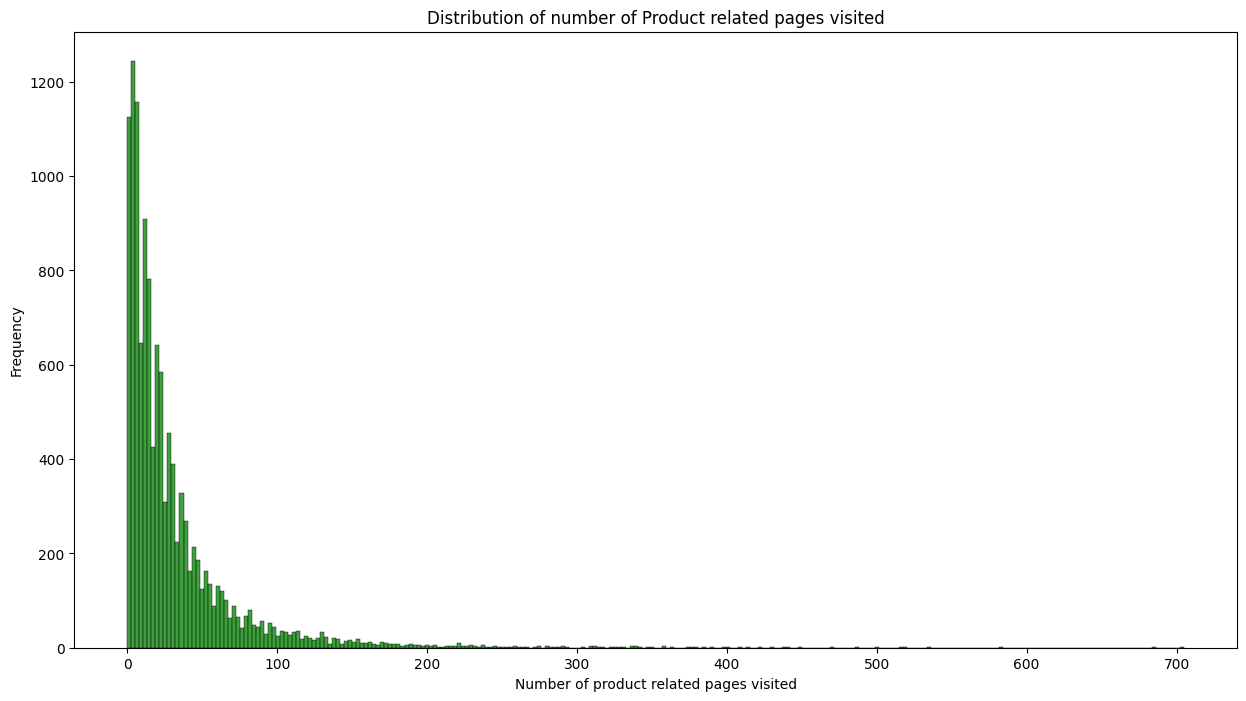

In [14]:
plt.figure(figsize=(15, 8))
sns.histplot(df['ProductRelatedCount'], kde=False, color='green')
plt.title('Distribution of number of Product related pages visited')
plt.xlabel('Number of product related pages visited')
plt.ylabel('Frequency')
plt.show()

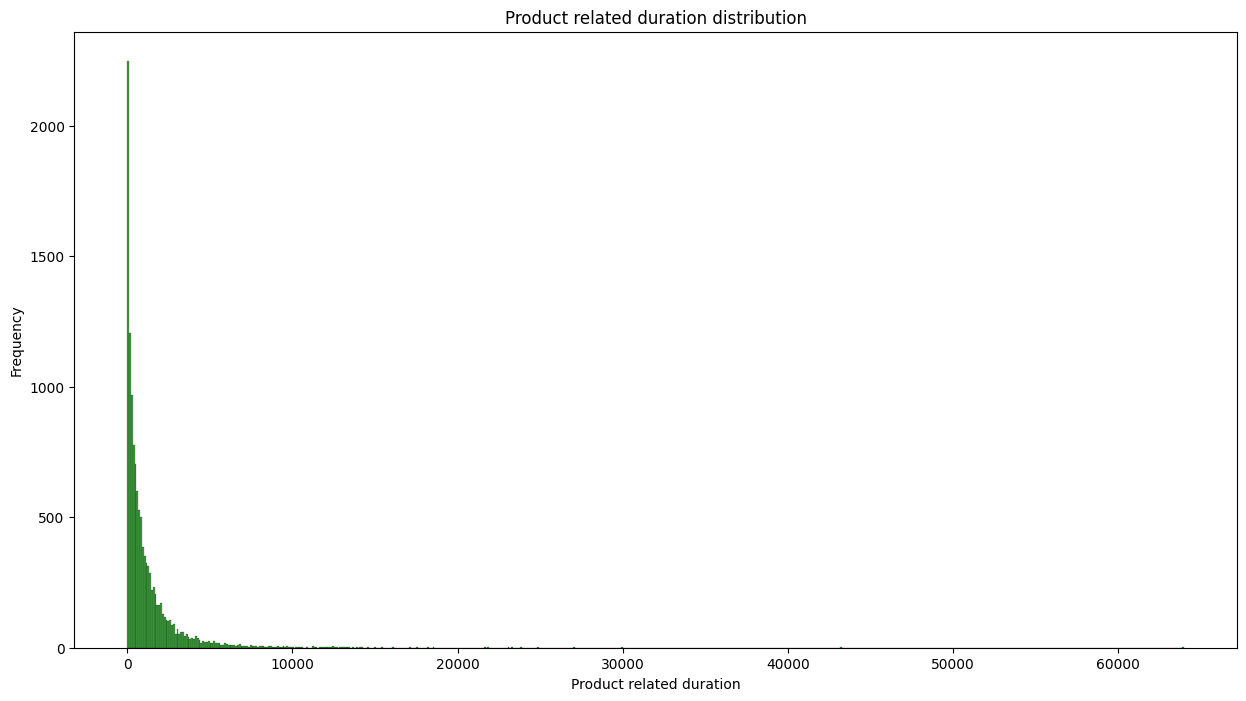

In [15]:
plt.figure(figsize=(15, 8))
sns.histplot(df['ProductRelated_Duration'], kde=False, color='green')
plt.title('Product related duration distribution')
plt.xlabel('Product related duration')
plt.ylabel('Frequency')
plt.show()

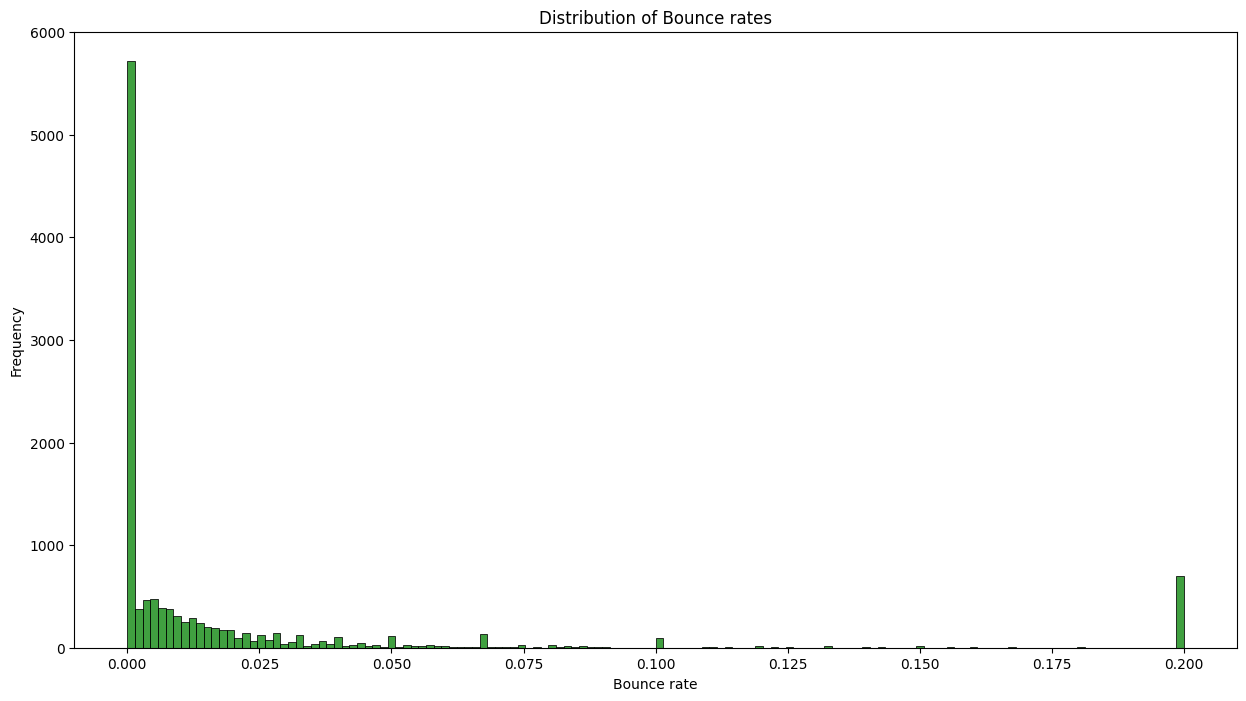

In [16]:
plt.figure(figsize=(15, 8))
sns.histplot(df['BounceRates'], kde=False, color='green')
plt.title('Distribution of Bounce rates')
plt.xlabel('Bounce rate')
plt.ylabel('Frequency')
plt.show()

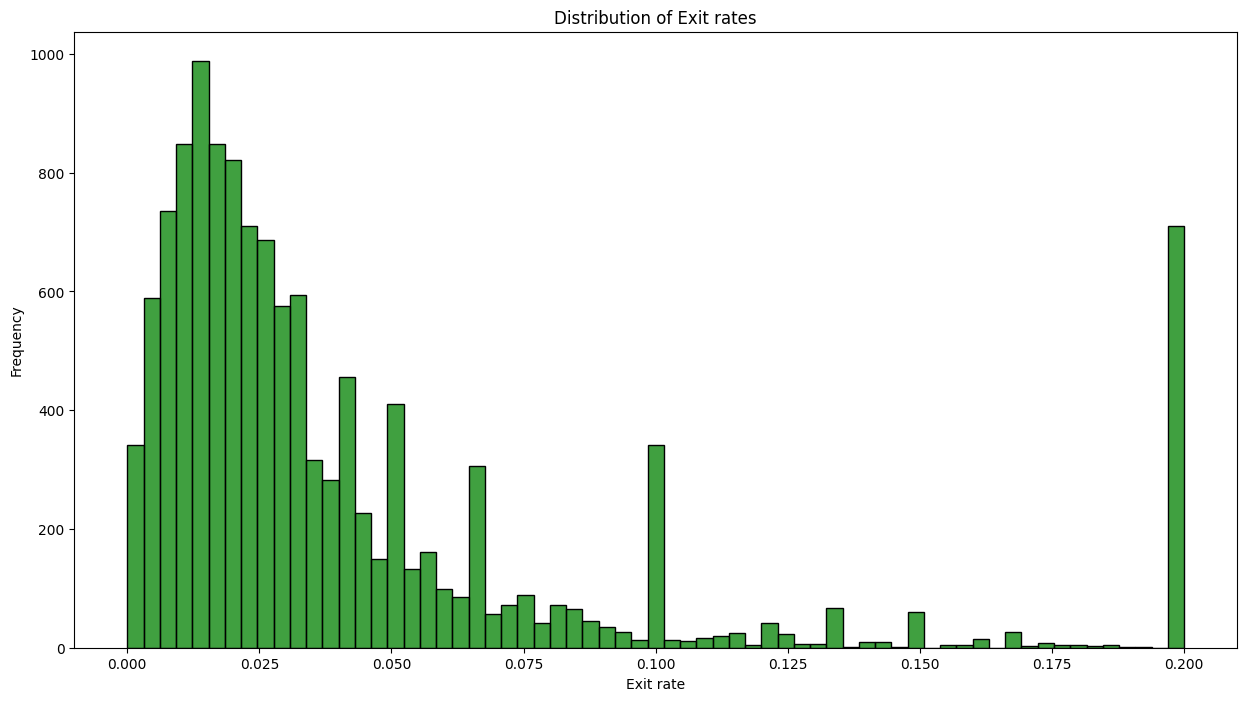

In [17]:
plt.figure(figsize=(15, 8))
sns.histplot(df['ExitRates'], kde=False, color='green')
plt.title('Distribution of Exit rates')
plt.xlabel('Exit rate')
plt.ylabel('Frequency')
plt.show()

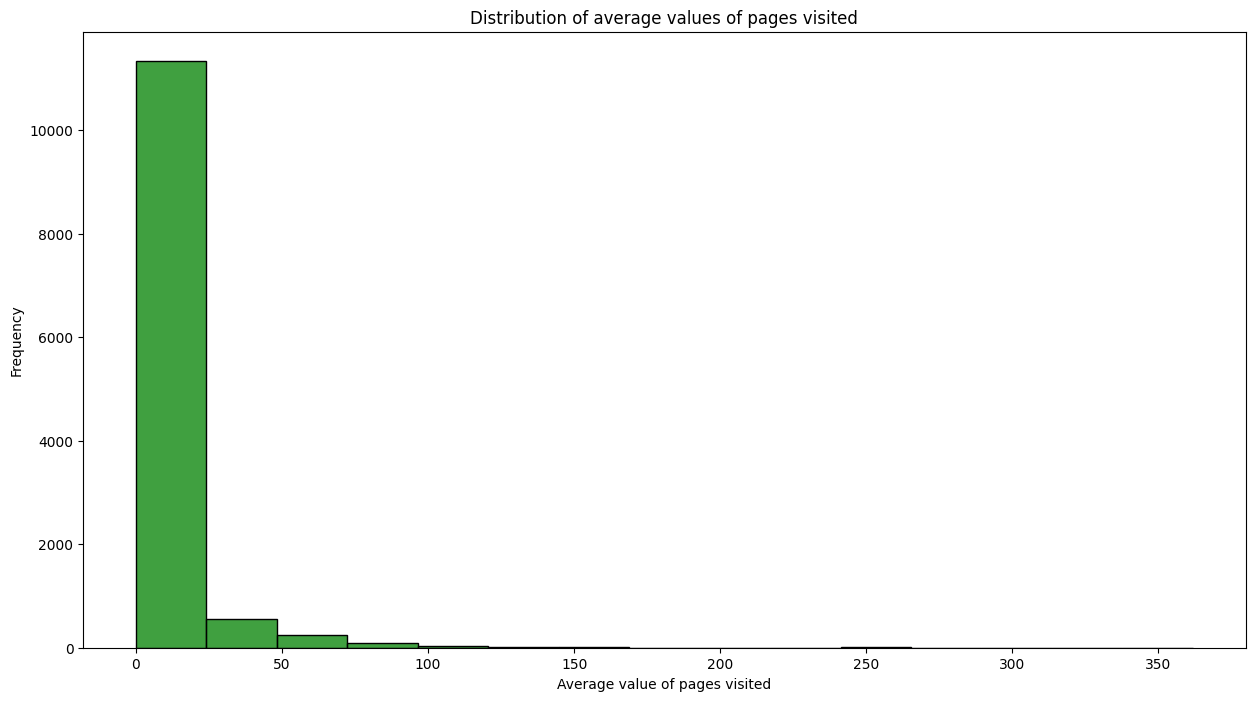

In [18]:
plt.figure(figsize=(15, 8))
sns.histplot(df['PageValues'], kde=False, color='green')
plt.title('Distribution of average values of pages visited')
plt.xlabel('Average value of pages visited')
plt.ylabel('Frequency')
plt.show()

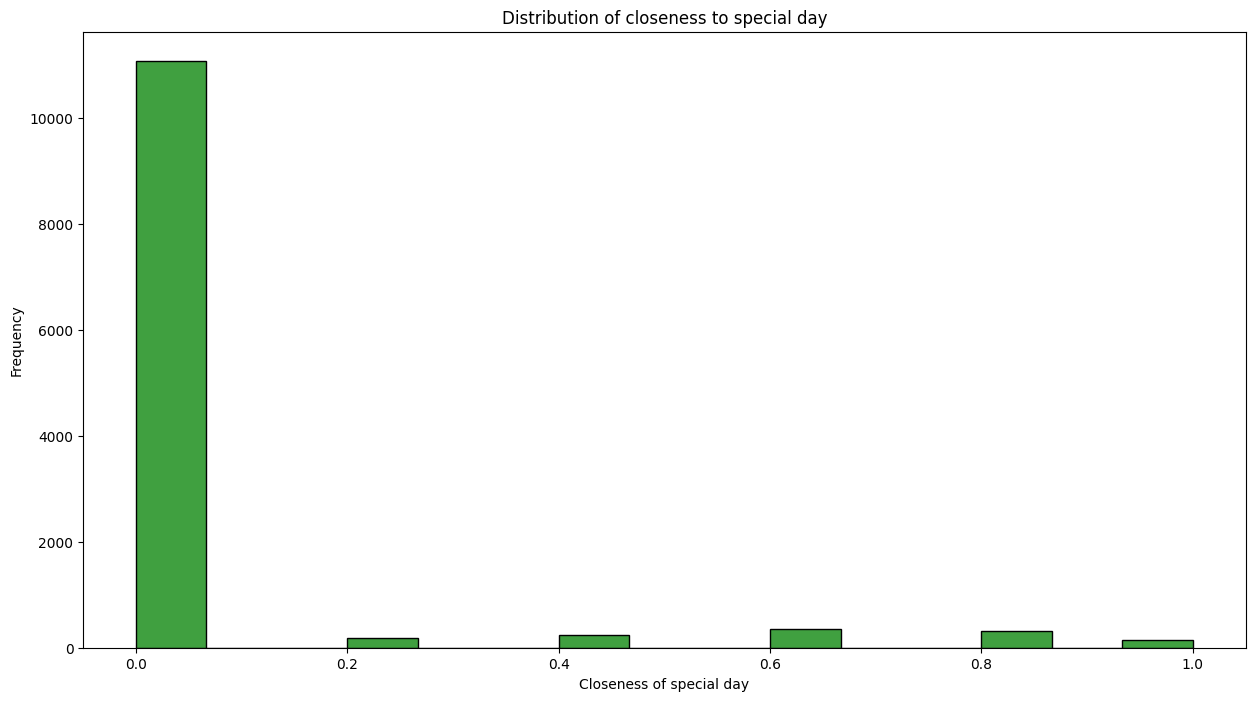

In [19]:
plt.figure(figsize=(15, 8))
sns.histplot(df['SpecialDay'], kde=False, color='green')
plt.title('Distribution of closeness to special day')
plt.xlabel('Closeness of special day')
plt.ylabel('Frequency')
plt.show()

Text(0.5, 1.0, 'Purchase rate by month')

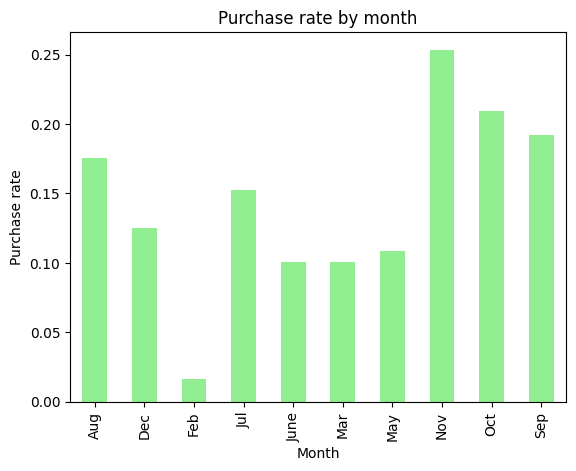

In [20]:
df.groupby('Month')['Revenue'].mean().plot(kind='bar', color='lightgreen')
plt.ylabel('Purchase rate')
plt.title('Purchase rate by month')

Text(0.5, 1.0, 'Purchase rate by Operating System')

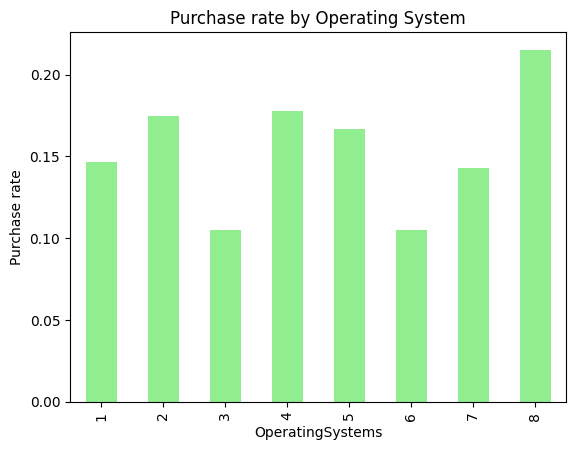

In [21]:
df.groupby('OperatingSystems')['Revenue'].mean().plot(kind='bar', color='lightgreen')
plt.ylabel('Purchase rate')
plt.title('Purchase rate by Operating System')

Text(0.5, 1.0, 'Purchase rate by Browser')

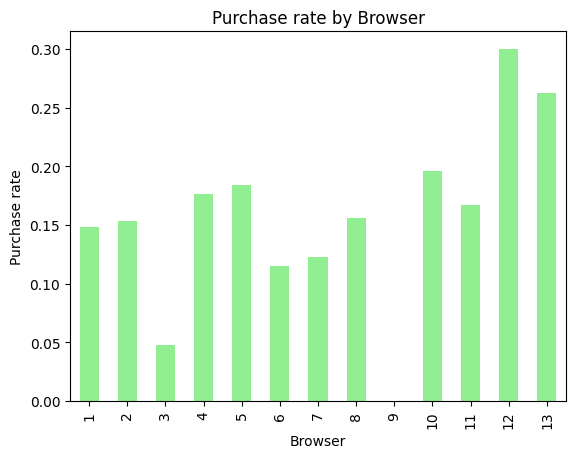

In [22]:
df.groupby('Browser')['Revenue'].mean().plot(kind='bar', color='lightgreen')
plt.ylabel('Purchase rate')
plt.title('Purchase rate by Browser')

Text(0.5, 1.0, 'Purchase rate by Region')

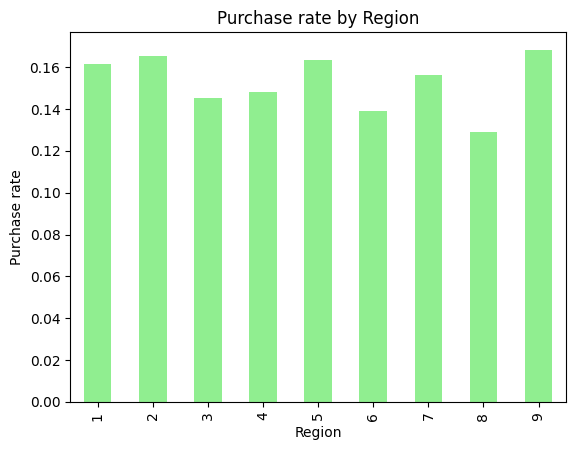

In [23]:
df.groupby('Region')['Revenue'].mean().plot(kind='bar', color='lightgreen')
plt.ylabel('Purchase rate')
plt.title('Purchase rate by Region')

Text(0.5, 1.0, 'Purchase rate by Traffic Type')

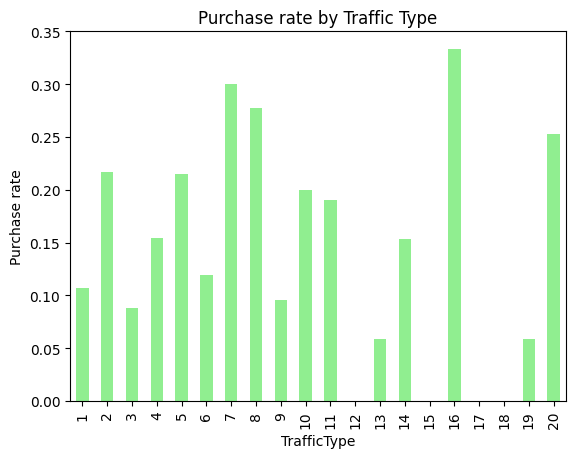

In [24]:
df.groupby('TrafficType')['Revenue'].mean().plot(kind='bar', color='lightgreen')
plt.ylabel('Purchase rate')
plt.title('Purchase rate by Traffic Type')

Text(0.5, 1.0, 'Purchase rate by Visitor Type')

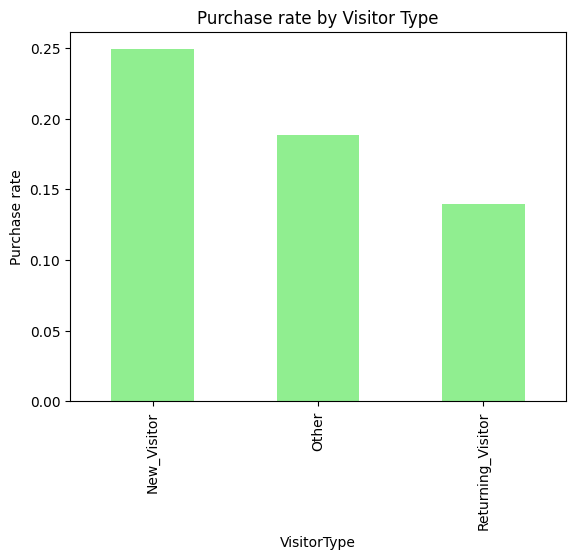

In [25]:
df.groupby('VisitorType')['Revenue'].mean().plot(kind='bar', color='lightgreen')
plt.ylabel('Purchase rate')
plt.title('Purchase rate by Visitor Type')

Text(0.5, 1.0, 'Purchase rate based on whether the visit was made on a weekend')

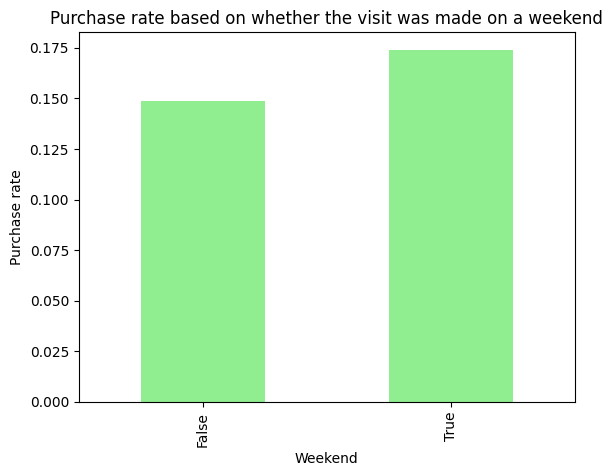

In [26]:
df.groupby('Weekend')['Revenue'].mean().plot(kind='bar', color='lightgreen')
plt.ylabel('Purchase rate')
plt.title('Purchase rate based on whether the visit was made on a weekend')

/tmp/ipykernel_746/1828732871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Blues')


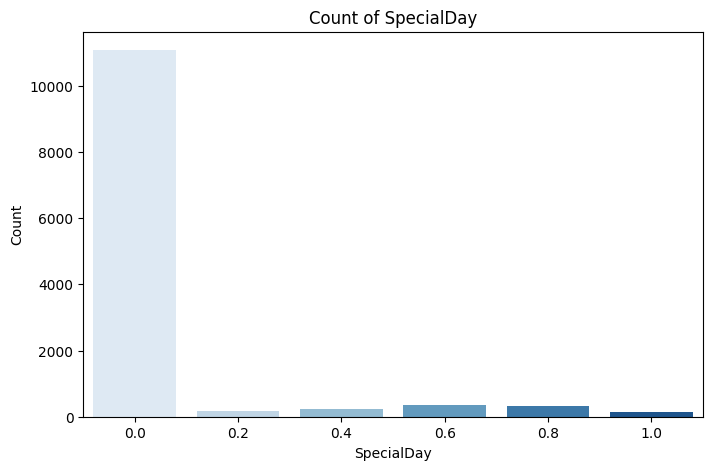

/tmp/ipykernel_746/1828732871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Blues')


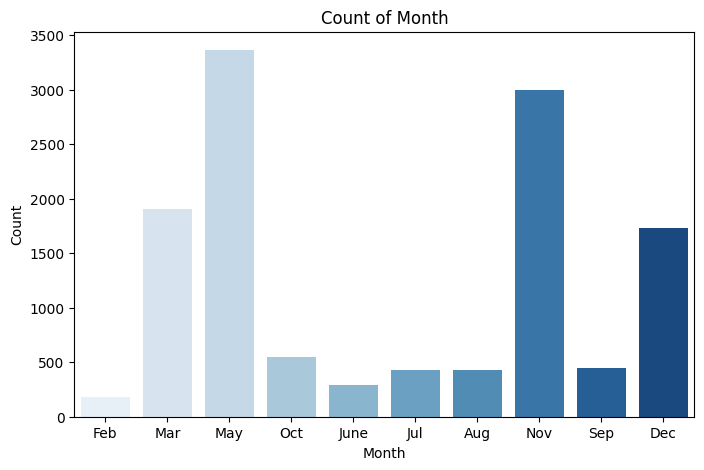

/tmp/ipykernel_746/1828732871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Blues')


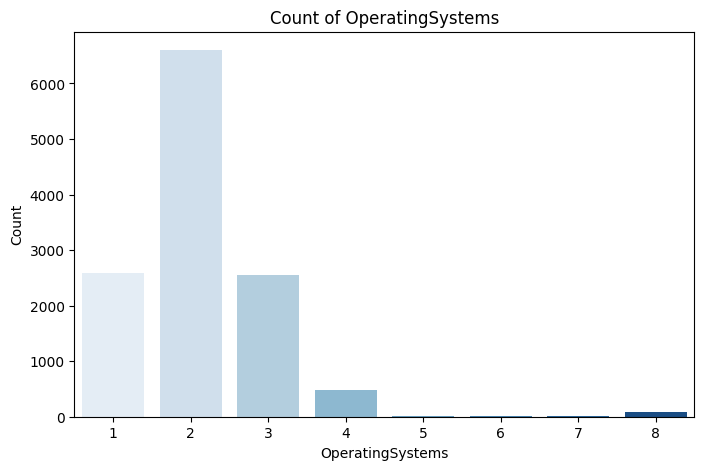

/tmp/ipykernel_746/1828732871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Blues')


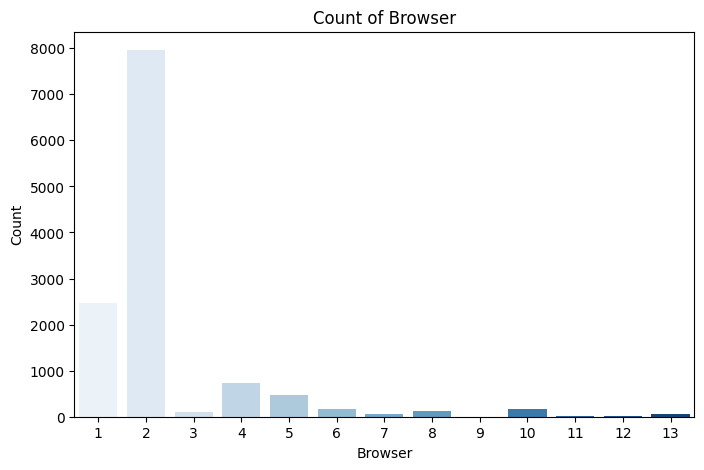

/tmp/ipykernel_746/1828732871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Blues')


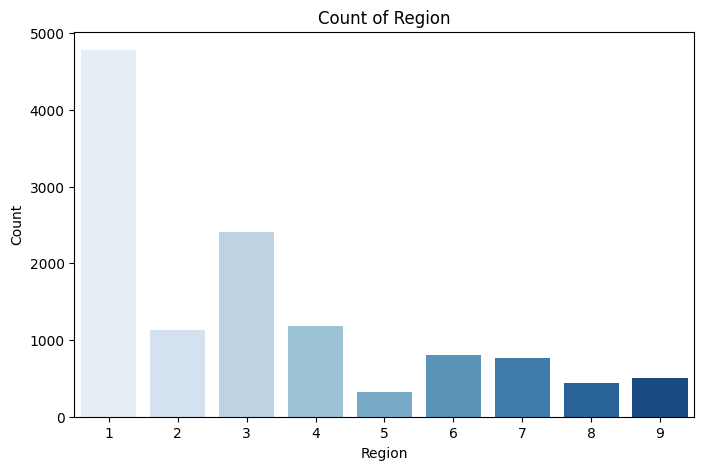

/tmp/ipykernel_746/1828732871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Blues')


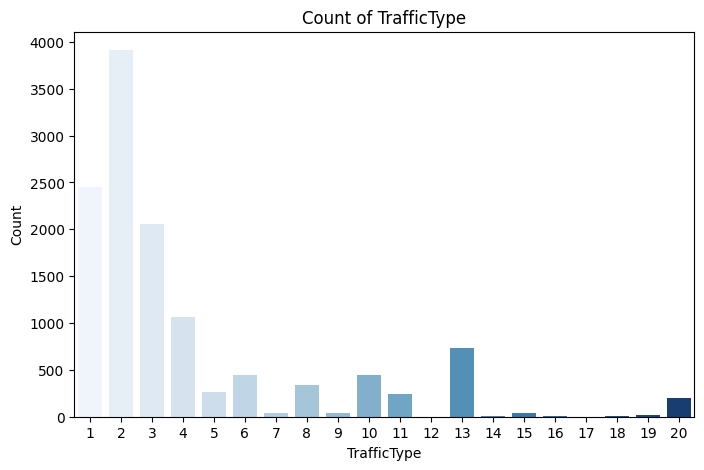

/tmp/ipykernel_746/1828732871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Blues')


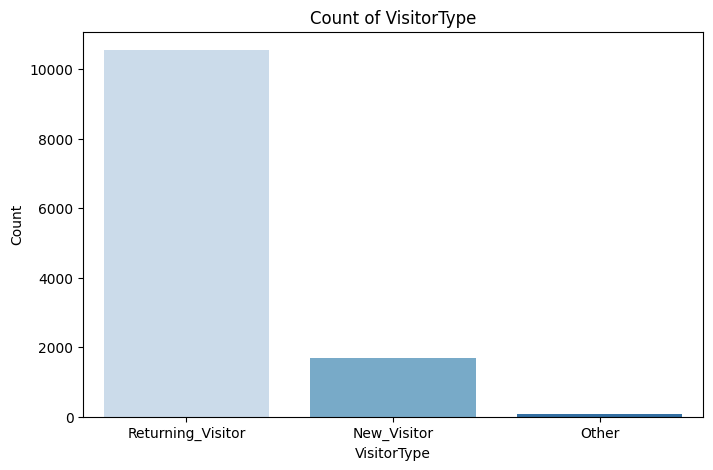

/tmp/ipykernel_746/1828732871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Blues')


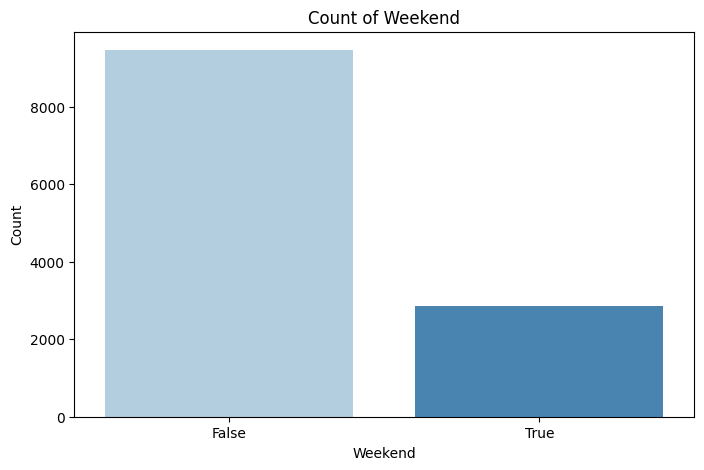

/tmp/ipykernel_746/1828732871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Blues')


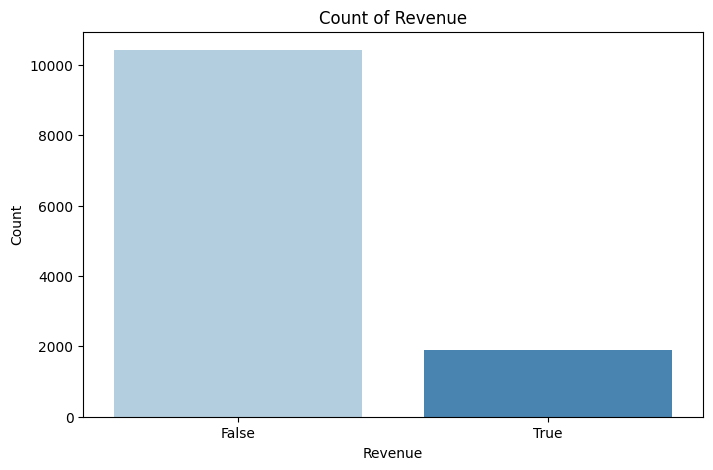

In [27]:
columns2=['SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']
for col in columns2:
  plt.figure(figsize=(8, 5))
  sns.countplot(data=df, x=col, palette='Blues')
  plt.title(f"Count of {col}")
  plt.ylabel("Count")
  plt.xlabel(col)
  plt.show()

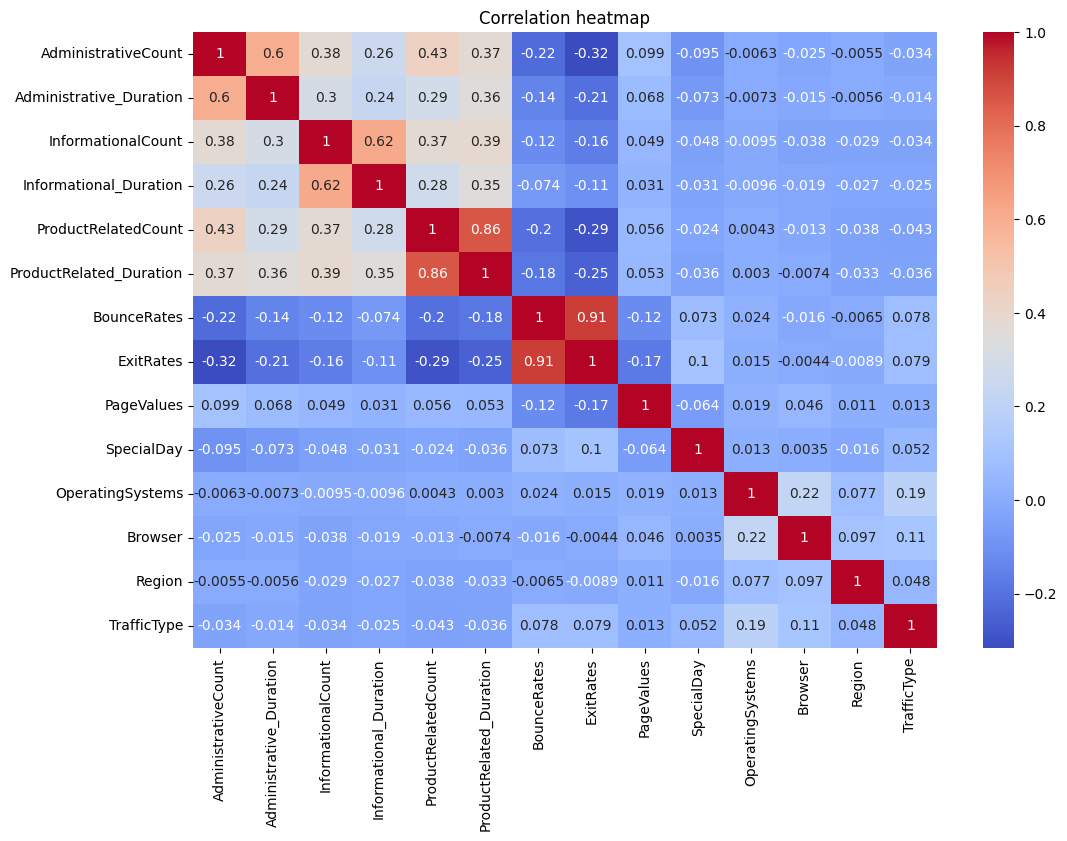

In [28]:
numerical_df=df.select_dtypes(include=np.number)
corr=numerical_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

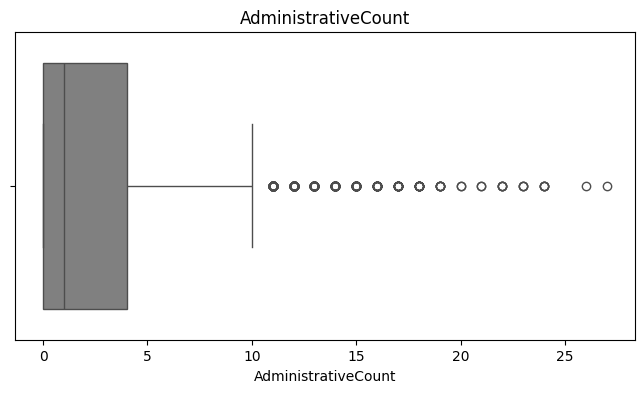

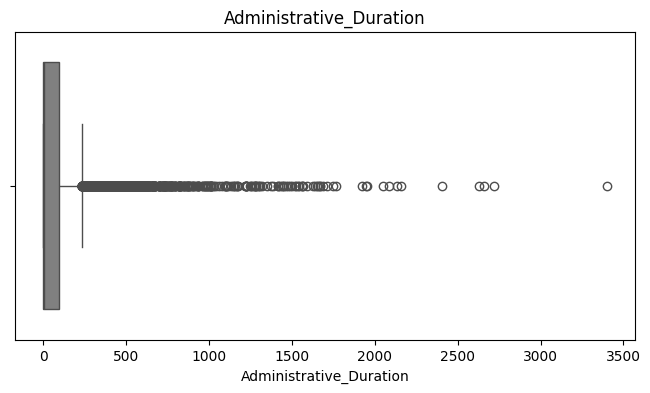

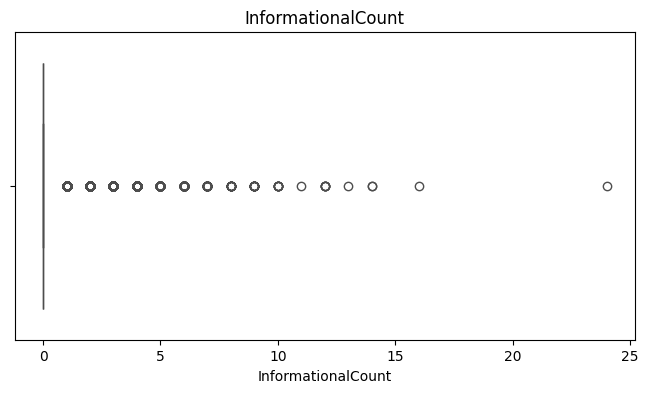

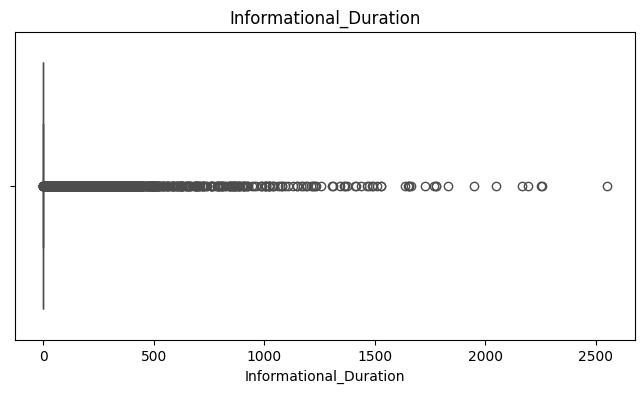

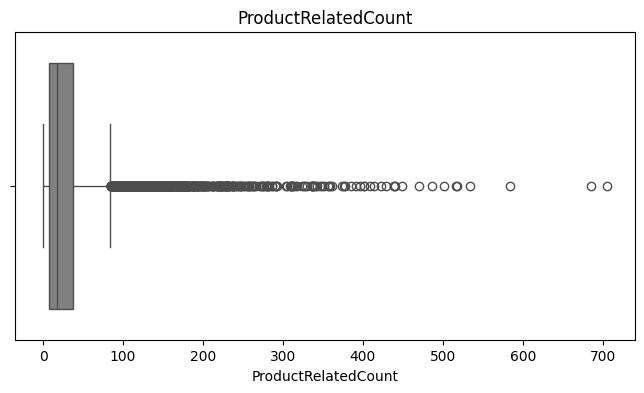

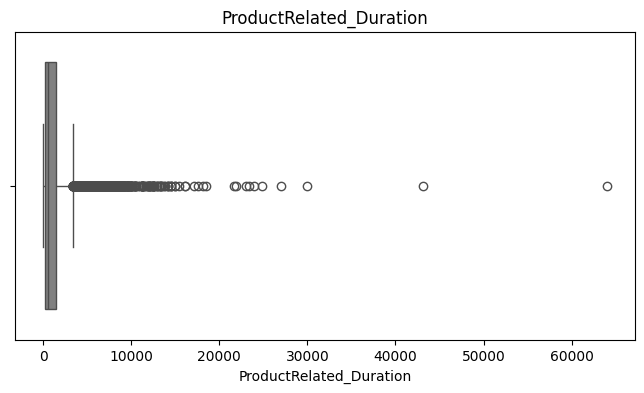

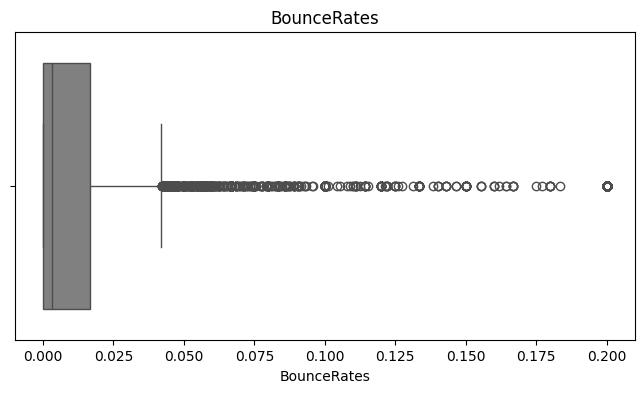

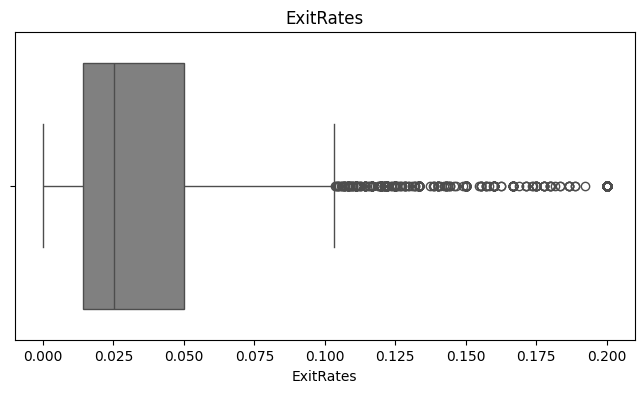

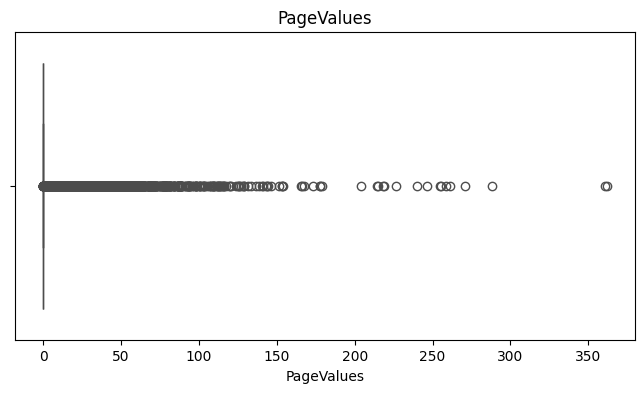

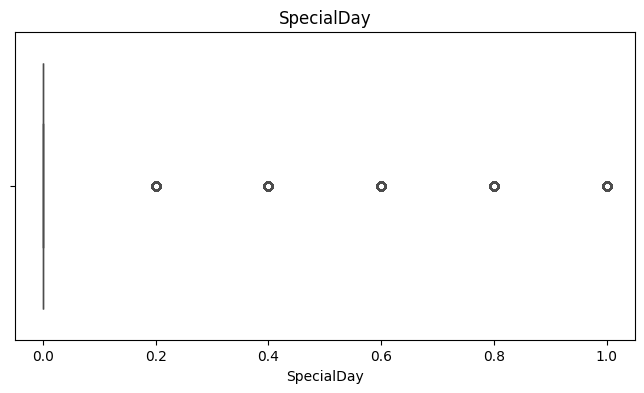

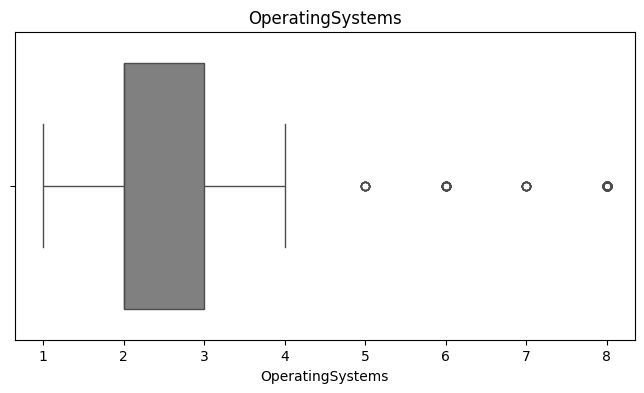

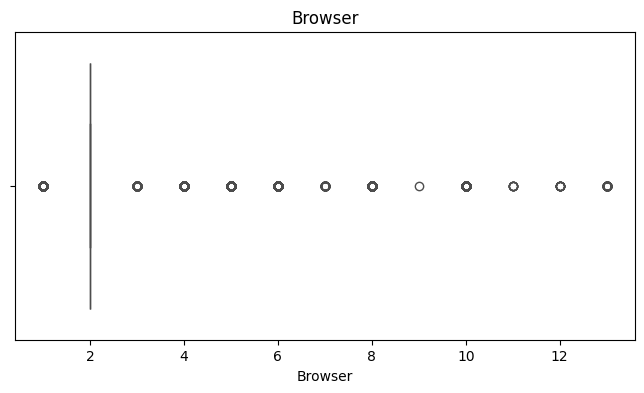

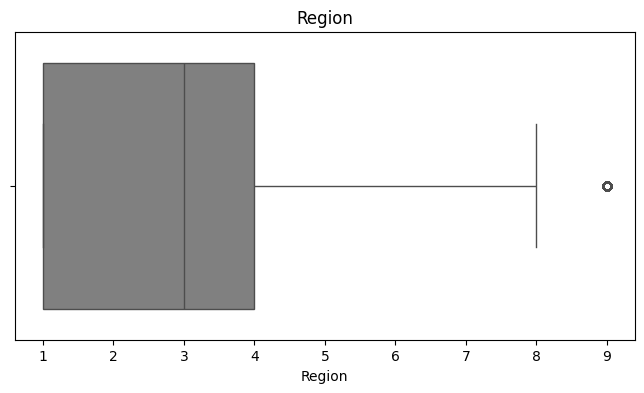

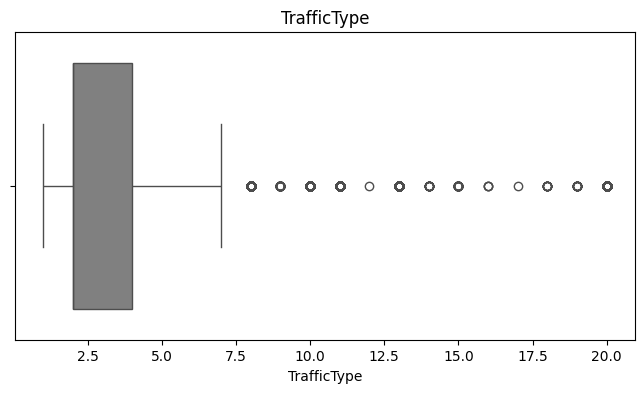

In [29]:
#Box plots
numerical_columns=numerical_df.columns

for col in numerical_columns:
  plt.figure(figsize=(8, 4))
  plt.title(col)
  sns.boxplot(x=col, data=df, color='gray')


In [30]:
df['Revenue']=df['Revenue'].replace({'False':0, 'True':1})

In [31]:
#Label encoding
le=LabelEncoder()
df['Weekend']=le.fit_transform(df['Weekend'])
df['Revenue']=le.fit_transform(df['Revenue'])

In [32]:
#One hot encoding
df=pd.get_dummies(df, columns=['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType'], drop_first=True, dtype=int)

In [33]:
df.head()

,AdministrativeCount,Administrative_Duration,InformationalCount,Informational_Duration,ProductRelatedCount,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1


In [34]:
X=df.drop('Revenue', axis=1)
y=df['Revenue']

In [35]:
#Train test split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [36]:
scaler=StandardScaler()

In [37]:
X_train=scaler.fit_transform(X_train)

In [38]:
X_test=scaler.transform(X_test)

In [39]:
classifier=LogisticRegression()

In [40]:
#Train the logistic regression model
classifier.fit(X_train, y_train)

LogisticRegression()

In [41]:
rfclassifier=RandomForestClassifier(
    n_estimators=400,
    max_samples=0.7,
    max_depth=17,
    min_samples_split=5
    )

In [42]:
#Train the random forest classifier model
rfclassifier.fit(X_train, y_train)

RandomForestClassifier(max_depth=17, max_samples=0.7, min_samples_split=5,
                       n_estimators=400)

In [43]:
y_predict1=classifier.predict(X_test)

In [44]:
y_predict2=rfclassifier.predict(X_test)

In [45]:
print("For Logistic Regression:")
print("Log loss", log_loss(y_test, y_predict1))
print("Accuracy score", accuracy_score(y_test, y_predict1))
print("Classification report")
print(classification_report(y_test, y_predict1))
print("Confusion matrix")
print(confusion_matrix(y_test, y_predict1))

For Logistic Regression:
Log loss 4.282558979323328
Accuracy score 0.8811841038118411
Classification report
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.74      0.36      0.49       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466

Confusion matrix
[[2035   49]
 [ 244  138]]


In [46]:
print("For Random Forest Classifier:")
print("Log loss", log_loss(y_test, y_predict2))
print("Accuracy score", accuracy_score(y_test, y_predict2))
print("Classification report")
print(classification_report(y_test, y_predict2))
print("Confusion matrix")
print(confusion_matrix(y_test, y_predict2))

For Random Forest Classifier:
Log loss 3.5955955935615656
Accuracy score 0.9002433090024331
Classification report
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2084
           1       0.77      0.50      0.61       382

    accuracy                           0.90      2466
   macro avg       0.84      0.74      0.78      2466
weighted avg       0.89      0.90      0.89      2466

Confusion matrix
[[2028   56]
 [ 190  192]]
